## Práctica Optimización para Grandes Volúmenes de Datos: Data streaming con Apache Kafka

Alumnos:
- Jaime Vaquero Rabahieh 
- Pedro Arroyo Urbina
- Zakaria Lasry Sahraoui 
- Pablo Chicharro Gómez

In [1]:
from kafka import KafkaConsumer
import json
import matplotlib.pyplot as plt
import time

In [2]:
from collections import defaultdict

# buffers por sensor
buffers = defaultdict(lambda: {
    "timestamps": [],
    "water_temperatures": [],
    "ph_levels": [],
    "turbidities": [],
    "dissolved_oxygen_levels": []
})

In [3]:


def initialize_consumer():
    kafka_topic = "water_quality"
    kafka_bootstrap_servers = ["localhost:9092"]
    GROUP_ID = "water_quality_processors"
    return KafkaConsumer(
        kafka_topic,
        bootstrap_servers=kafka_bootstrap_servers,
        key_deserializer=lambda k: k.decode("utf-8") if k else "unknown_sensor",
        value_deserializer=lambda m: json.loads(m.decode("utf-8")),
        auto_offset_reset="latest",
        enable_auto_commit=True,
        group_id=GROUP_ID,
    )



In [4]:
def update_plot(consumer):
    try:
        for message in consumer:
            sensor_id = message.key  # <-- viene de la KEY de Kafka
            sensor_data = message.value
            print(f"Received sensor={sensor_id}: {sensor_data}")

            # recuperar buffers del sensor
            buf = buffers[sensor_id]
            timestamps = buf["timestamps"]
            water_temperatures = buf["water_temperatures"]
            ph_levels = buf["ph_levels"]
            turbidities = buf["turbidities"]
            dissolved_oxygen_levels = buf["dissolved_oxygen_levels"]

            # Update data storage (solo del sensor)
            timestamps.append(sensor_data['timestamp'])
            water_temperatures.append(sensor_data['water_temperature'])
            ph_levels.append(sensor_data['ph_level'])
            turbidities.append(sensor_data['turbidity'])
            dissolved_oxygen_levels.append(sensor_data['dissolved_oxygen'])

            # Keep only the last 100 entries
            if len(timestamps) > 100:
                timestamps.pop(0)
                water_temperatures.pop(0)
                ph_levels.pop(0)
                turbidities.pop(0)
                dissolved_oxygen_levels.pop(0)

            # Plot
            plt.figure(figsize=(10, 8))

            plt.subplot(2, 2, 1)
            plt.plot(timestamps, water_temperatures, label="Water Temperature", color="blue")
            plt.title(f"Water Temperature ({sensor_id})")
            plt.ylabel("°C")

            plt.subplot(2, 2, 2)
            plt.plot(timestamps, ph_levels, label="pH Level", color="green")
            plt.title(f"pH Level ({sensor_id})")
            plt.ylabel("pH")

            plt.subplot(2, 2, 3)
            plt.plot(timestamps, turbidities, label="Turbidity", color="orange")
            plt.title(f"Turbidity ({sensor_id})")
            plt.ylabel("NTU")

            plt.subplot(2, 2, 4)
            plt.plot(timestamps, dissolved_oxygen_levels, label="Dissolved Oxygen", color="red")
            plt.title(f"Dissolved Oxygen ({sensor_id})")
            plt.ylabel("mg/L")

            plt.tight_layout()

            # Guardar un plot por sensor
            plt.savefig(f"water_quality_plot_{sensor_id}.png")
            plt.close()

            break  # Process one message at a time

    except KeyboardInterrupt:
        print("Stopped consuming messages.")
        consumer.close()

Subscribed to Kafka topic 'water_quality'.
Received sensor=1: {'sensor_id': '1', 'timestamp': 1772360932, 'water_temperature': 26.282593491809525, 'ph_level': 8.141264418353257, 'turbidity': 32.45, 'dissolved_oxygen': 5.88}
Received sensor=4: {'sensor_id': '4', 'timestamp': 1772360932, 'water_temperature': 26.91626353751473, 'ph_level': 8.31471949648281, 'turbidity': 12.29, 'dissolved_oxygen': 11.44}
Received sensor=1: {'sensor_id': '1', 'timestamp': 1772360933, 'water_temperature': 27.768471459711417, 'ph_level': 8.30191039038959, 'turbidity': 26.01, 'dissolved_oxygen': 11.51}
Received sensor=3: {'sensor_id': '3', 'timestamp': 1772360933, 'water_temperature': 28.11493119162563, 'ph_level': 8.183644216230018, 'turbidity': 37.61, 'dissolved_oxygen': 10.6}
Received sensor=4: {'sensor_id': '4', 'timestamp': 1772360933, 'water_temperature': 27.50451680856196, 'ph_level': 7.816409850219159, 'turbidity': 45.82, 'dissolved_oxygen': 9.86}
Received sensor=3: {'sensor_id': '3', 'timestamp': 1772

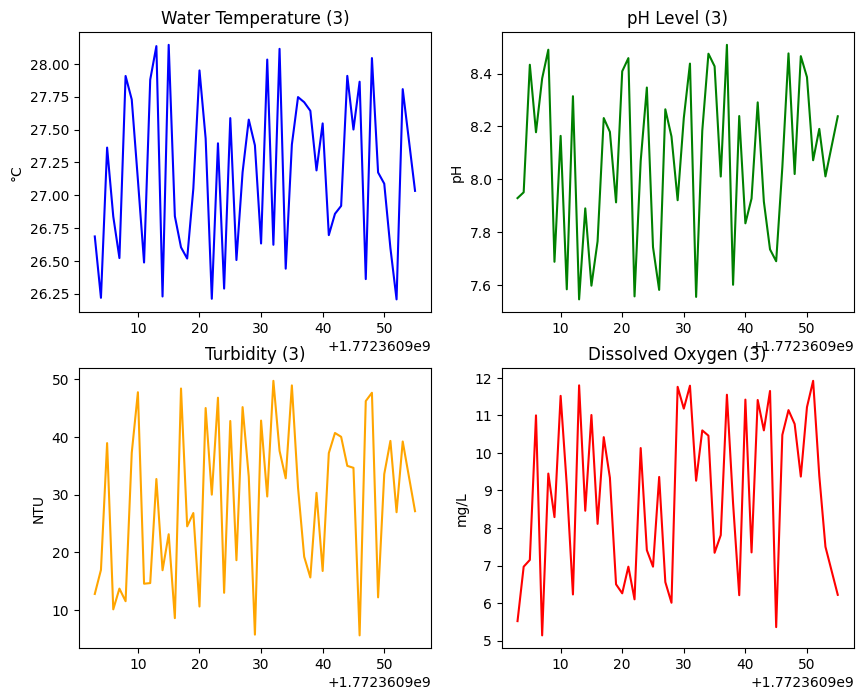

In [6]:
consumer = initialize_consumer()
print("Subscribed to Kafka topic 'water_quality'.")

try:
    while True:
        update_plot(consumer)
except KeyboardInterrupt:
    print("Stopped visualization.")
    consumer.close()